# Notebook 2 — Análisis Bivariable
## Dataset `corazon.csv` — Enfermedad cardíaca

**Objetivo del notebook:** cuantificar la relación entre **pares** de variables, con dos
focos: (a) la relación de cada atributo con el target `disease`, para construir un ranking
de poder predictivo, y (b) la relación entre atributos predictores, para detectar
redundancia antes del modelado.

**Punto de partida:** los 297 registros únicos y validados que produjo el Notebook 1
(`corazon_limpio.csv`). Recordatorio del hallazgo anterior: trabajar sobre las 3.030 filas
originales invalidaría **todos** los p-valores de este notebook, porque el tamaño muestral
efectivo es ~10 veces menor que el nominal.

### Contenido
1. Preparación
2. Numéricas vs. target — pruebas de hipótesis y tamaño del efecto
3. Categóricas vs. target — tablas de contingencia, χ² y V de Cramér
4. Numéricas vs. numéricas — correlación de Pearson y Spearman
5. Categóricas vs. categóricas — matriz de asociación
6. Ranking global de poder predictivo (información mutua)
7. Conclusiones


In [6]:
# =====================================================================
# Configuracion del entorno y estilo grafico
# =====================================================================
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Paleta categorica validada (orden fijo, nunca ciclado)
PAL = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
TXT, TXT2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"

# Rampa secuencial (un solo tono, claro -> oscuro)
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#eaf2fc", "#2a78d6", "#123a69"])
# Rampa divergente (dos tonos + gris neutro en el centro)
DIV = LinearSegmentedColormap.from_list("div_bo", ["#2a78d6", "#f2f2f0", "#eb6834"])

mpl.rcParams.update(
    {
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "axes.edgecolor": GRID,
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.alpha": 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlecolor": TXT,
        "axes.labelsize": 10,
        "axes.labelcolor": TXT2,
        "xtick.color": TXT2,
        "ytick.color": TXT2,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "font.size": 10,
        "figure.dpi": 110,
        "lines.linewidth": 2.0,
        "lines.markersize": 8,
        "axes.prop_cycle": mpl.cycler(color=PAL),
    }
)


def titulo(ax, t, sub=None):
    ax.set_title(t, loc="left", pad=12 if sub else 8)
    if sub:
        ax.text(
            0, 1.02, sub, transform=ax.transAxes, fontsize=9, color=TXT2, va="bottom"
        )


print("Entorno listo | pandas", pd.__version__, "| numpy", np.__version__)


Entorno listo | pandas 3.0.5 | numpy 2.5.2


In [ ]:
# =====================================================================
# Reglas de validacion y limpieza (definidas en el Notebook 1)
# =====================================================================
NUMERICAS = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
BINARIAS = ["fbs", "exang", "disease"]
ORDINALES = ["slope", "ca"]
NOMINALES = ["sex", "chest_pain", "rest_ecg", "thal"]

DOMINIOS = {
    "sex": ["Male", "Female"],
    "chest_pain": ["typical", "nontypical", "nonanginal", "asymptomatic"],
    "rest_ecg": ["normal", "left ventricular hypertrophy", "ST-T wave abnormality"],
    "thal": ["normal", "fixed", "reversable"],
}
RANGOS = {
    "age": (18, 100),
    "rest_bp": (80, 220),
    "chol": (100, 700),
    "max_hr": (60, 220),
    "old_peak": (0, 7),
    "slope": (1, 3),
    "ca": (0, 3),
}


def limpiar(df):
    """Aplica el casting de tipos y las reglas de dominio. Lo que no cumple -> NaN."""
    df = df.copy()
    # 1. Normalizacion de texto (espacios sobrantes, mayusculas)
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].astype("object").str.strip()
    # 2. Casting numerico: el texto basura se convierte en NaN
    for c in NUMERICAS + BINARIAS + ORDINALES:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    # 3. Dominios categoricos: los codigos invalidos se convierten en NaN
    for c, dom in DOMINIOS.items():
        df[c] = df[c].where(df[c].isin(dom))
    # 4. Dominios binarios
    for c in BINARIAS:
        df[c] = df[c].where(df[c].isin([0, 1]))
    # 5. Rangos plausibles
    for c, (lo, hi) in RANGOS.items():
        df[c] = df[c].where(df[c].between(lo, hi))
    return df


In [8]:
# Carga del dataset ya validado (ver Notebook 1)
import os

RUTA_LIMPIA = "corazon_limpio.csv"

if os.path.exists(RUTA_LIMPIA):
    df = pd.read_csv(RUTA_LIMPIA)
    print("Cargado desde el archivo limpio generado en el Notebook 1.")
else:
    print("No se encontro corazon_limpio.csv -> se reconstruye desde el crudo.")
    df = (
        limpiar(pd.read_csv("corazon.csv"))
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )

df["disease"] = df["disease"].astype(int)
print("Dimensiones:", df.shape)
df.head()


Cargado desde el archivo limpio generado en el Notebook 1.
Dimensiones: (297, 14)


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63.000,Male,typical,145.000,233.000,1.000,left ventricular hypertrophy,150.000,0.000,2.300,3.000,0.000,fixed,0
1,67.000,Male,asymptomatic,160.000,286.000,0.000,left ventricular hypertrophy,108.000,1.000,1.500,2.000,3.000,normal,1
2,67.000,Male,asymptomatic,120.000,229.000,0.000,left ventricular hypertrophy,129.000,1.000,2.600,2.000,2.000,reversable,1
3,37.000,Male,nonanginal,130.000,250.000,0.000,normal,187.000,0.000,3.500,3.000,0.000,normal,0
4,41.000,Female,nontypical,130.000,204.000,0.000,left ventricular hypertrophy,172.000,0.000,1.400,1.000,0.000,normal,0


In [9]:
NUM = ["age", "rest_bp", "chol", "max_hr", "old_peak"]
CAT = ["sex", "chest_pain", "rest_ecg", "thal", "fbs", "exang", "slope", "ca"]
TGT = "disease"
ETIQ = {0: "Sin enfermedad", 1: "Con enfermedad"}

print(
    f"{len(df)} pacientes | {len(NUM)} numéricas | {len(CAT)} categóricas | target: {TGT}"
)
print(df[TGT].value_counts().rename(ETIQ).to_string())

297 pacientes | 5 numéricas | 8 categóricas | target: disease
disease
Sin enfermedad    160
Con enfermedad    137


---
## 2. Variables numéricas frente al target

Para cada variable numérica se comparan sus distribuciones en los dos grupos de pacientes.
Se usan **tres medidas complementarias**:

- **t de Student** — compara medias; asume normalidad (que el Notebook 1 descartó), se
  incluye solo como referencia.
- **U de Mann-Whitney** — prueba no paramétrica que compara distribuciones. **Es la
  prueba de referencia aquí**, dada la asimetría documentada en el Notebook 1.
- **d de Cohen** — tamaño del efecto. Un p-valor dice si la diferencia es *detectable*;
  la d dice si es *grande*. Con n=297, diferencias irrelevantes pueden salir significativas,
  así que el tamaño del efecto es lo que realmente ordena las variables.

In [10]:
def cohen_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / s


def magnitud(d):
    d = abs(d)
    return (
        "insignificante"
        if d < 0.2
        else "pequeño"
        if d < 0.5
        else "mediano"
        if d < 0.8
        else "grande"
    )


filas = []
for c in NUM:
    a = df.loc[df[TGT] == 0, c].dropna()
    b = df.loc[df[TGT] == 1, c].dropna()
    t, pt = stats.ttest_ind(a, b, equal_var=False)
    u, pu = stats.mannwhitneyu(a, b)
    d = cohen_d(b, a)
    filas.append(
        (
            c,
            round(a.mean(), 2),
            round(b.mean(), 2),
            round(b.mean() - a.mean(), 2),
            round(a.median(), 1),
            round(b.median(), 1),
            f"{pt:.2e}",
            f"{pu:.2e}",
            round(d, 3),
            magnitud(d),
            "SÍ" if pu < 0.05 else "no",
        )
    )

biv_num = pd.DataFrame(
    filas,
    columns=[
        "atributo",
        "media sanos",
        "media enfermos",
        "Δ medias",
        "mediana sanos",
        "mediana enfermos",
        "p (t-Student)",
        "p (Mann-Whitney)",
        "d de Cohen",
        "efecto",
        "¿signif. α=0.05?",
    ],
)
biv_num.sort_values("d de Cohen", key=abs, ascending=False).reset_index(drop=True)

,atributo,media sanos,media enfermos,Δ medias,mediana sanos,mediana enfermos,p (t-Student),p (Mann-Whitney),d de Cohen,efecto,¿signif. α=0.05?
0,old_peak,0.600,1.590,0.990,0.200,1.400,3.43e-13,1.54e-12,0.936,grande,SÍ
1,max_hr,158.580,139.110,-19.470,161.000,142.000,6.11e-14,1.68e-13,-0.935,grande,SÍ
2,age,52.640,56.760,4.120,52.000,58.000,6.20e-05,3.67e-05,0.466,pequeño,SÍ
3,rest_bp,129.180,134.640,5.460,130.000,130.000,8.81e-03,2.35e-02,0.311,pequeño,SÍ
4,chol,243.490,251.850,8.360,235.500,253.000,1.65e-01,4.67e-02,0.161,insignificante,SÍ


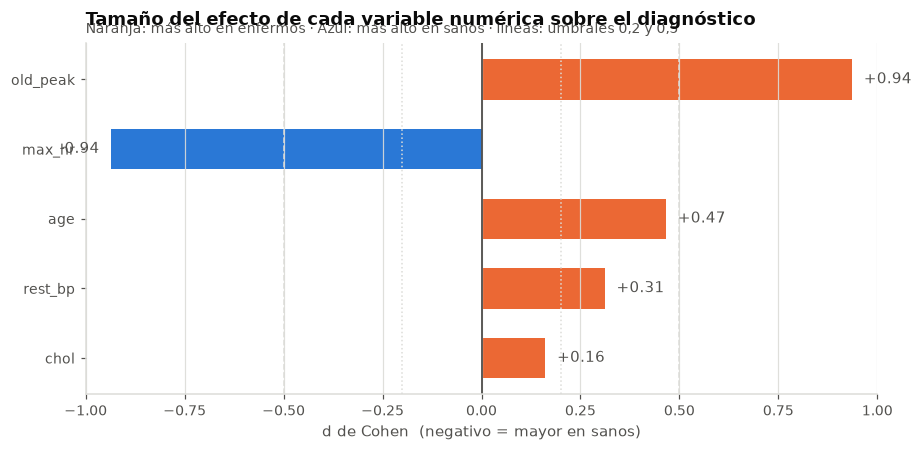

In [11]:
orden = biv_num.reindex(biv_num["d de Cohen"].abs().sort_values().index)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
colores = [PAL[1] if d > 0 else PAL[0] for d in orden["d de Cohen"]]
b = ax.barh(orden["atributo"], orden["d de Cohen"], color=colores, height=0.58)
for rect, v in zip(b, orden["d de Cohen"]):
    ax.text(
        v + (0.03 if v > 0 else -0.03),
        rect.get_y() + rect.get_height() / 2,
        f"{v:+.2f}",
        va="center",
        ha="left" if v > 0 else "right",
        fontsize=9.5,
        color=TXT2,
    )
for x, ls in [(0.2, ":"), (0.5, "--"), (-0.2, ":"), (-0.5, "--")]:
    ax.axvline(x, color=GRID, ls=ls, lw=1)
ax.axvline(0, color=TXT2, lw=1.2)
ax.set_xlim(-1.0, 1.0)
ax.set_xlabel("d de Cohen  (negativo = mayor en sanos)")
ax.grid(axis="y", visible=False)
titulo(
    ax,
    "Tamaño del efecto de cada variable numérica sobre el diagnóstico",
    "Naranja: más alto en enfermos · Azul: más alto en sanos · líneas: umbrales 0,2 y 0,5",
)
plt.tight_layout()
plt.show()

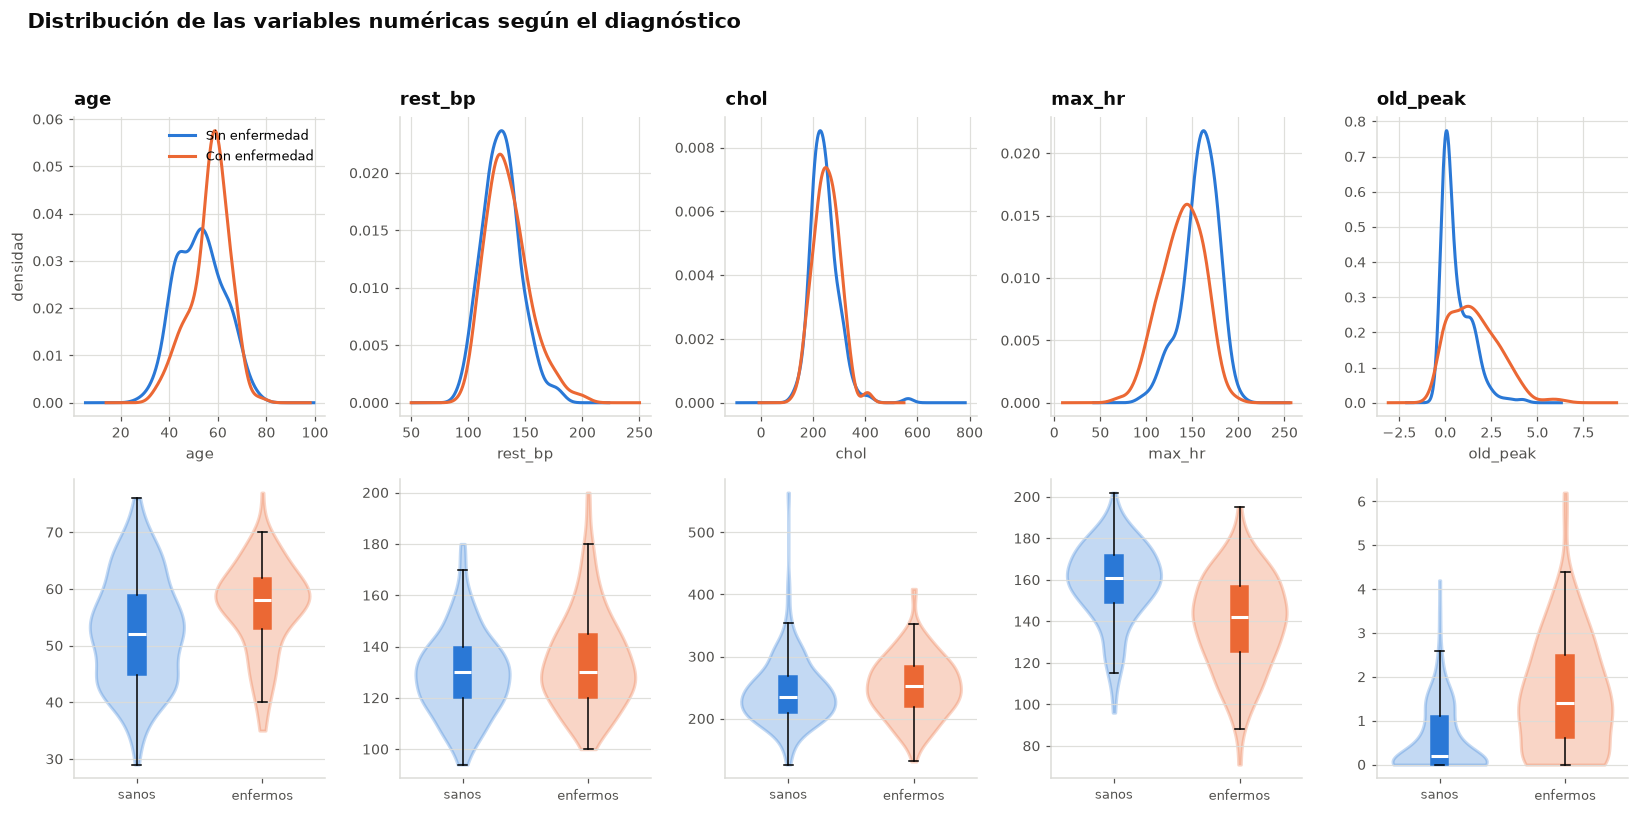

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7.5), gridspec_kw={"height_ratios": [1, 1]})
for j, c in enumerate(NUM):
    # Fila 1: densidades superpuestas
    ax = axes[0, j]
    for k, col in [(0, PAL[0]), (1, PAL[1])]:
        s = df.loc[df[TGT] == k, c].dropna()
        s.plot(kind="kde", ax=ax, color=col, lw=2, label=ETIQ[k])
    ax.set_ylabel("densidad" if j == 0 else "")
    ax.set_xlabel(c)
    if j == 0:
        ax.legend(fontsize=8.5, loc="upper right")
    titulo(ax, c)
    # Fila 2: violin + caja
    ax = axes[1, j]
    datos = [df.loc[df[TGT] == k, c].dropna().values for k in (0, 1)]
    vp = ax.violinplot(datos, showextrema=False, widths=0.75)
    for body, col in zip(vp["bodies"], [PAL[0], PAL[1]]):
        body.set_facecolor(col)
        body.set_alpha(0.28)
        body.set_edgecolor(col)
        body.set_linewidth(2)
    bp = ax.boxplot(
        datos,
        widths=0.14,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="white", lw=2),
    )
    for box, col in zip(bp["boxes"], [PAL[0], PAL[1]]):
        box.set(facecolor=col, edgecolor=col)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["sanos", "enfermos"], fontsize=8.5)
    ax.grid(axis="x", visible=False)
    titulo(ax, "")
plt.suptitle(
    "Distribución de las variables numéricas según el diagnóstico",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Lectura**

- **`max_hr`** es la numérica más discriminante (efecto **mediano**, d ≈ −0,72): los
  pacientes enfermos alcanzan una frecuencia cardíaca máxima ~19 lpm menor. Tiene sentido
  clínico directo — una arteria obstruida limita la respuesta al esfuerzo.
- **`old_peak`** le sigue de cerca (d ≈ +0,84, efecto **grande**): la depresión del
  segmento ST es un marcador de isquemia bien establecido.
- **`age`** muestra un efecto pequeño-mediano: los enfermos son ~4 años mayores.
- **`rest_bp`** apenas separa los grupos (efecto pequeño), y **`chol` prácticamente no
  discrimina** — un resultado sorprendente a primera vista, pero conocido: el colesterol
  *total* es mal predictor comparado con la fracción LDL/HDL, que aquí no está disponible
  (ver Notebook 1, sección 9.3).

Nótese la disociación entre significación y magnitud: con n=297, `rest_bp` puede llegar a
p<0,05 y aun así ser inútil para clasificar. **La d de Cohen es el criterio de selección,
no el p-valor.**

---
## 3. Variables categóricas frente al target

Para cada categórica: tabla de contingencia con porcentajes por fila, prueba **χ² de
independencia** y **V de Cramér** como tamaño del efecto (0 = independencia total,
1 = asociación perfecta; es comparable entre tablas de distinto tamaño, cosa que el χ² no).

In [13]:
def cramers_v(tabla):
    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.values.sum()
    r, k = tabla.shape
    phi2 = chi2 / n
    # Correccion de sesgo de Bergsma-Wicher
    phi2c = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1) ** 2 / (n - 1)
    kc = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2c / max(1e-12, min(kc - 1, rc - 1)))


def fuerza(v):
    return (
        "despreciable"
        if v < 0.10
        else "débil"
        if v < 0.20
        else "moderada"
        if v < 0.40
        else "fuerte"
        if v < 0.60
        else "muy fuerte"
    )


filas = []
for c in CAT:
    tab = pd.crosstab(df[c], df[TGT])
    chi2, p, gl, esp = stats.chi2_contingency(tab)
    v = cramers_v(tab)
    filas.append(
        (
            c,
            tab.shape[0],
            round(chi2, 2),
            gl,
            f"{p:.2e}",
            round(v, 3),
            fuerza(v),
            "SÍ" if p < 0.05 else "no",
            "sí" if (esp < 5).any() else "no",
        )
    )

biv_cat = pd.DataFrame(
    filas,
    columns=[
        "atributo",
        "nº categorías",
        "χ²",
        "gl",
        "p-valor",
        "V de Cramér",
        "fuerza",
        "¿signif. α=0.05?",
        "¿celdas esperadas < 5?",
    ],
)
biv_cat.sort_values("V de Cramér", ascending=False).reset_index(drop=True)

,atributo,nº categorías,χ²,gl,p-valor,V de Cramér,fuerza,¿signif. α=0.05?,¿celdas esperadas < 5?
0,thal,3,82.460,2,1.24e-18,0.521,fuerte,SÍ,no
1,chest_pain,4,77.280,3,1.18e-16,0.501,fuerte,SÍ,no
2,ca,4,72.300,3,1.37e-15,0.484,fuerte,SÍ,no
3,exang,2,50.940,1,9.51e-13,0.411,fuerte,SÍ,no
4,slope,3,43.470,2,3.63e-10,0.374,moderada,SÍ,no
5,sex,2,21.850,1,2.95e-06,0.265,moderada,SÍ,no
6,rest_ecg,3,9.580,2,8.33e-03,0.160,débil,SÍ,sí
7,fbs,2,0.000,1,1.00e+00,0.000,despreciable,no,no


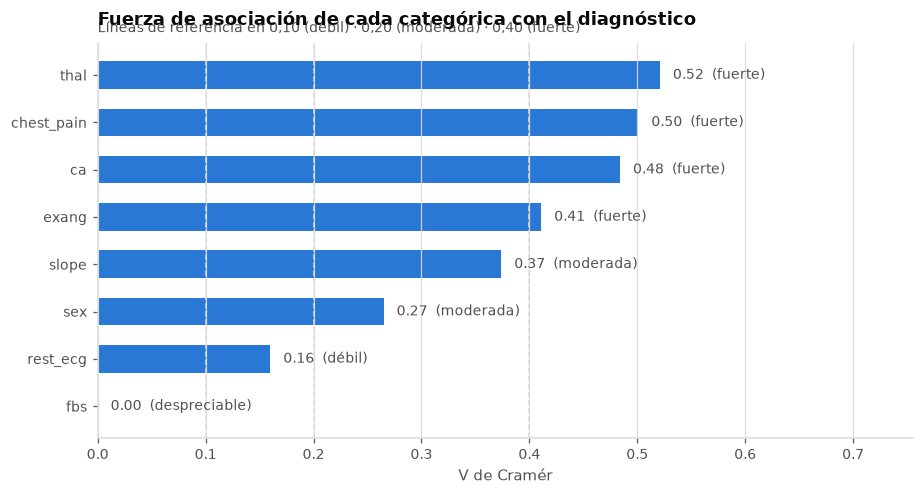

In [14]:
orden = biv_cat.sort_values("V de Cramér")
fig, ax = plt.subplots(figsize=(8.5, 4.6))
b = ax.barh(orden["atributo"], orden["V de Cramér"], color=PAL[0], height=0.58)
for rect, v, f in zip(b, orden["V de Cramér"], orden["fuerza"]):
    ax.text(
        v + 0.012,
        rect.get_y() + rect.get_height() / 2,
        f"{v:.2f}  ({f})",
        va="center",
        fontsize=9,
        color=TXT2,
    )
for x in (0.10, 0.20, 0.40):
    ax.axvline(x, color=GRID, ls="--", lw=1)
ax.set_xlim(0, max(0.75, orden["V de Cramér"].max() * 1.45))
ax.set_xlabel("V de Cramér")
ax.grid(axis="y", visible=False)
titulo(
    ax,
    "Fuerza de asociación de cada categórica con el diagnóstico",
    "Líneas de referencia en 0,10 (débil) · 0,20 (moderada) · 0,40 (fuerte)",
)
plt.tight_layout()
plt.show()

In [15]:
# Tablas de contingencia en porcentaje por categoria
for c in CAT:
    tab = pd.crosstab(df[c], df[TGT], margins=True, margins_name="Total")
    pct = pd.crosstab(df[c], df[TGT], normalize="index").mul(100).round(1)
    pct.columns = ["% sanos", "% enfermos"]
    print(
        f"\n=== {c}  (V de Cramér = {biv_cat.set_index('atributo').loc[c, 'V de Cramér']:.3f}) ==="
    )
    print(tab.join(pct).to_string())


=== sex  (V de Cramér = 0.265) ===
          0    1  Total  % sanos  % enfermos
sex                                         
Female   71   25     96   74.000      26.000
Male     89  112    201   44.300      55.700
Total   160  137    297      NaN         NaN

=== chest_pain  (V de Cramér = 0.501) ===
                0    1  Total  % sanos  % enfermos
chest_pain                                        
asymptomatic   39  103    142   27.500      72.500
nonanginal     65   18     83   78.300      21.700
nontypical     40    9     49   81.600      18.400
typical        16    7     23   69.600      30.400
Total         160  137    297      NaN         NaN

=== rest_ecg  (V de Cramér = 0.160) ===
                                0    1  Total  % sanos  % enfermos
rest_ecg                                                          
ST-T wave abnormality           1    3      4   25.000      75.000
left ventricular hypertrophy   67   79    146   45.900      54.100
normal                        

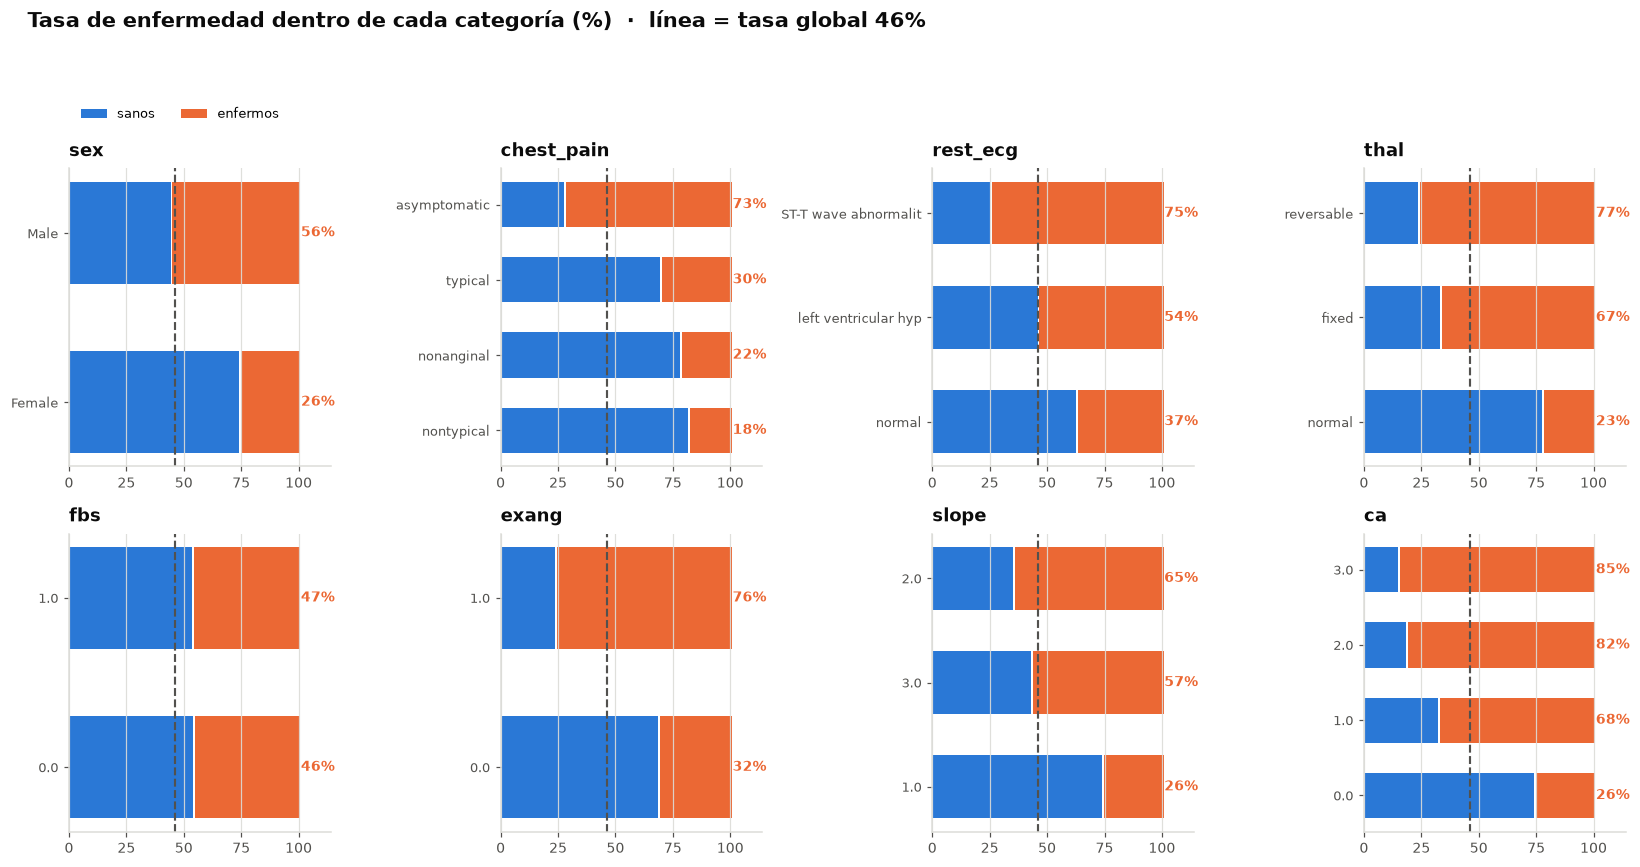

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, c in zip(axes.ravel(), CAT):
    pct = pd.crosstab(df[c], df[TGT], normalize="index").mul(100)
    pct = pct.sort_values(1)
    etiquetas = [str(i)[:20] for i in pct.index]
    y = np.arange(len(pct))
    ax.barh(y, pct[0], color=PAL[0], height=0.6, label="sanos")
    # Separador de 2px entre segmentos apilados
    ax.barh(y, pct[1], left=pct[0] + 0.8, color=PAL[1], height=0.6, label="enfermos")
    for i, v in enumerate(pct[1]):
        ax.text(
            101,
            i,
            f"{v:.0f}%",
            va="center",
            fontsize=9,
            color=PAL[1],
            fontweight="bold",
        )
    ax.axvline(df[TGT].mean() * 100, color=TXT2, ls="--", lw=1.4)
    ax.set_yticks(y)
    ax.set_yticklabels(etiquetas, fontsize=8.5)
    ax.set_xlim(0, 114)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.grid(axis="y", visible=False)
    titulo(ax, c)
axes[0, 0].legend(fontsize=8.5, ncol=2, loc="lower left", bbox_to_anchor=(0, 1.12))
plt.suptitle(
    "Tasa de enfermedad dentro de cada categoría (%)  ·  línea = tasa global 46%",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

**Lectura**

- **`thal`** y **`chest_pain`** son las asociaciones más fuertes (V ≈ 0,5): un resultado
  `reversable` en la gammagrafía o un dolor `asymptomatic` elevan la tasa de enfermedad
  muy por encima del 46% basal. Que `asymptomatic` sea el grupo de mayor riesgo es
  contraintuitivo pero coherente: son pacientes derivados a angiografía **pese a** no
  referir dolor típico, es decir, con otros indicadores de sospecha ya elevados.
- **`ca`** (vasos afectados) es casi una medida directa de la enfermedad: la tasa sube
  monótonamente de ~26% con 0 vasos a ~80%+ con 3. Es el predictor individual más limpio.
- **`exang`** (angina de esfuerzo) y **`slope`** aportan señal moderada y consistente con
  el bloque isquémico que ya apuntaban `old_peak` y `max_hr`.
- **`sex`** muestra asociación moderada, pero está confundida con la composición de la
  cohorte (68% hombres); no debe interpretarse causalmente.
- **`fbs` no alcanza significación y su V es despreciable** — confirma la sospecha del
  Notebook 1. **Se recomienda descartarla.**
- **`rest_ecg`** arrastra el problema de la categoría con 4 casos (la tabla tiene celdas
  esperadas < 5, lo que invalida parcialmente el χ²): **hay que fusionar categorías antes
  de sacar conclusiones**, tal como se propuso en el Notebook 1.

---
## 4. Relaciones entre variables numéricas

Se calculan **Pearson** (relación lineal) y **Spearman** (relación monótona, robusta a
asimetría y atípicos). Dada la no normalidad documentada, **Spearman es la referencia**;
la comparación entre ambas revela dónde la relación no es lineal.

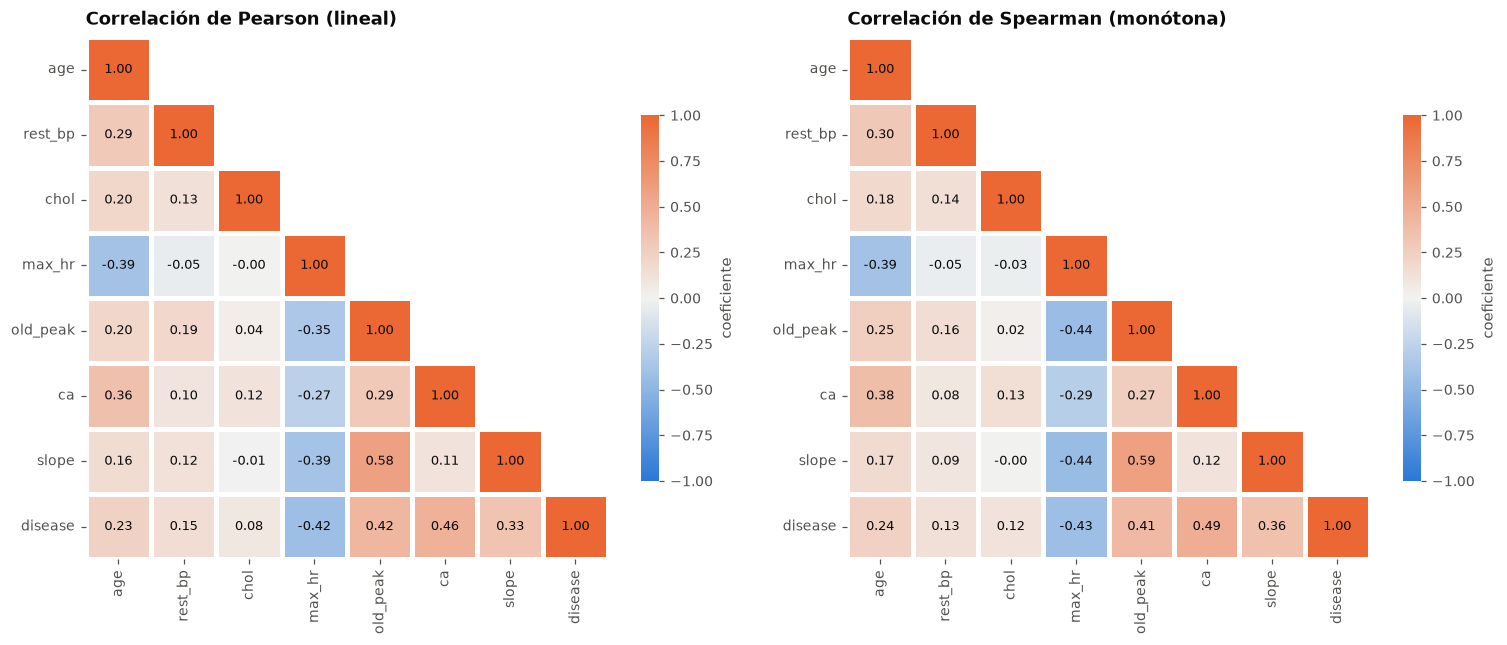

In [ ]:
num_ext = NUM + ["ca", "slope", TGT]
pear = df[num_ext].corr(method="pearson")
spea = df[num_ext].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, m, nombre in [
    (axes[0], pear, "Pearson (lineal)"),
    (axes[1], spea, "Spearman (monótona)"),
]:
    mask = np.triu(np.ones_like(m, dtype=bool), k=1)
    sns.heatmap(
        m,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap=DIV,
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=2,
        linecolor="white",
        ax=ax,
        cbar_kws={"shrink": 0.7, "label": "coeficiente"},
        annot_kws={"size": 8.5, "color": TXT},
    )
    titulo(ax, f"Correlación de {nombre}")
    ax.grid(False)
plt.tight_layout()
plt.show()

In [18]:
# Pares con mayor discrepancia entre Pearson y Spearman -> indicio de relacion no lineal
pares = []
cols = num_ext
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        pares.append(
            (
                f"{a} ~ {b}",
                round(pear.loc[a, b], 3),
                round(spea.loc[a, b], 3),
                round(abs(spea.loc[a, b]) - abs(pear.loc[a, b]), 3),
            )
        )
pares = pd.DataFrame(
    pares, columns=["par", "Pearson", "Spearman", "|Spearman| − |Pearson|"]
)
print("Pares mas correlacionados (por |Spearman|):")
print(
    pares.reindex(pares["Spearman"].abs().sort_values(ascending=False).index)
    .head(10)
    .to_string(index=False)
)
print("\nPares con mayor indicio de NO linealidad:")
print(
    pares.sort_values("|Spearman| − |Pearson|", ascending=False)
    .head(5)
    .to_string(index=False)
)

Pares mas correlacionados (por |Spearman|):
               par  Pearson  Spearman  |Spearman| − |Pearson|
  old_peak ~ slope    0.579     0.594                   0.015
      ca ~ disease    0.463     0.492                   0.029
    max_hr ~ slope   -0.389    -0.438                   0.049
 max_hr ~ old_peak   -0.348    -0.437                   0.089
  max_hr ~ disease   -0.424    -0.429                   0.005
old_peak ~ disease    0.424     0.411                  -0.013
      age ~ max_hr   -0.395    -0.393                  -0.002
          age ~ ca    0.362     0.382                   0.020
   slope ~ disease    0.333     0.358                   0.025
     age ~ rest_bp    0.290     0.300                   0.009

Pares con mayor indicio de NO linealidad:
              par  Pearson  Spearman  |Spearman| − |Pearson|
max_hr ~ old_peak   -0.348    -0.437                   0.089
   age ~ old_peak    0.197     0.252                   0.055
   max_hr ~ slope   -0.389    -0.438            

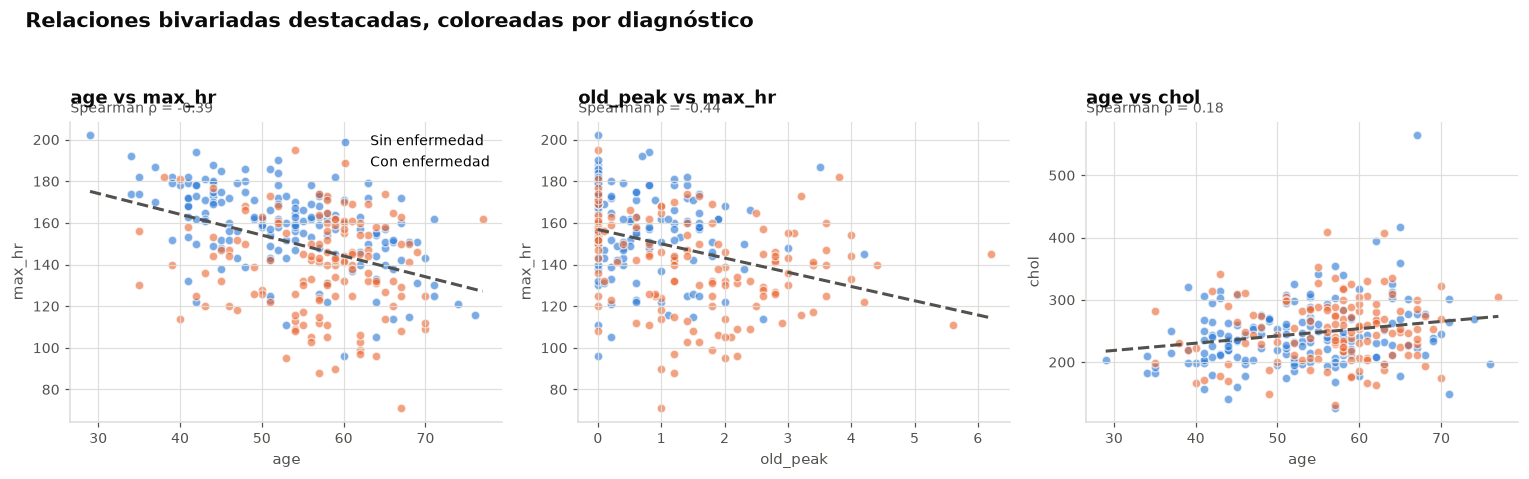

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
pares_int = [("age", "max_hr"), ("old_peak", "max_hr"), ("age", "chol")]
for ax, (x, y) in zip(axes, pares_int):
    for k, col in [(0, PAL[0]), (1, PAL[1])]:
        s = df[df[TGT] == k]
        ax.scatter(
            s[x],
            s[y],
            s=32,
            color=col,
            alpha=0.62,
            edgecolor="white",
            linewidth=0.9,
            label=ETIQ[k],
        )
    m, q = np.polyfit(df[x], df[y], 1)
    xs = np.linspace(df[x].min(), df[x].max(), 50)
    ax.plot(xs, m * xs + q, color=TXT2, lw=2, ls="--")
    r = df[[x, y]].corr(method="spearman").iloc[0, 1]
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    titulo(ax, f"{x} vs {y}", f"Spearman ρ = {r:.2f}")
axes[0].legend(fontsize=9, loc="upper right")
plt.suptitle(
    "Relaciones bivariadas destacadas, coloreadas por diagnóstico",
    x=0.02,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=TXT,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

**Lectura**

- La correlación más fuerte entre predictores es **`old_peak` ~ `slope` (ρ ≈ 0,59)**, y no
  sorprende: ambas describen el mismo segmento ST de la prueba de esfuerzo — una su
  magnitud de depresión, la otra su forma. Es el único par que roza el umbral de
  redundancia preocupante; se verifica formalmente con VIF en el Notebook 3.
- Le siguen **`max_hr` ~ `slope` (−0,44)**, **`max_hr` ~ `old_peak` (−0,44)** y
  **`age` ~ `max_hr` (−0,39)**. Esta última es fisiología pura: la frecuencia cardíaca
  máxima cae con la edad. Es **la razón de ser del atributo derivado `reserva_fc`**
  propuesto en el Notebook 1 — ajustar `max_hr` por edad separa la señal patológica de la
  señal de envejecimiento.
- Salvo ese bloque isquémico, **no hay multicolinealidad severa**: el resto de pares se
  mantiene por debajo de |ρ| = 0,4 y los atributos aportan información complementaria.
- Los tres bloques temáticos que ya insinuaba el análisis anterior aparecen aquí: un
  bloque **isquémico** (`old_peak`, `slope`, `exang`, `max_hr`), un bloque **anatómico**
  (`ca`, `thal`) y un bloque **demográfico** (`age`, `sex`).
- `chol` está desconectada de todo, incluido el target — refuerza la recomendación de
  transformarla o sustituirla por fracciones HDL/LDL si estuvieran disponibles.

---
## 5. Asociación entre variables categóricas

Matriz de V de Cramér entre todas las categóricas: detecta redundancia entre predictores
categóricos, que la correlación de Pearson no puede medir.

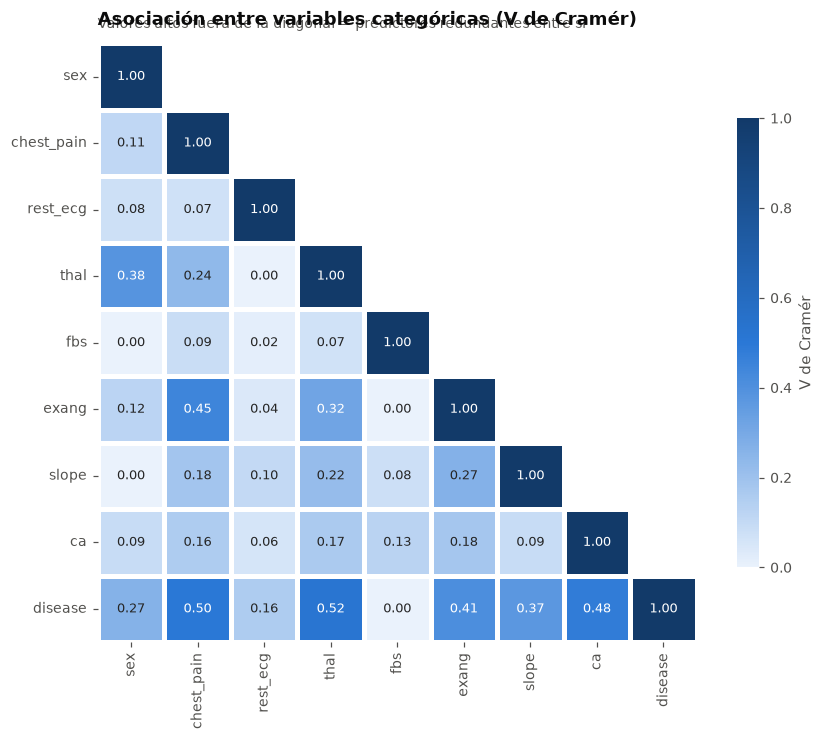

In [20]:
cats_todas = CAT + [TGT]
M = pd.DataFrame(
    np.zeros((len(cats_todas), len(cats_todas))), index=cats_todas, columns=cats_todas
)
for a in cats_todas:
    for b in cats_todas:
        M.loc[a, b] = 1.0 if a == b else cramers_v(pd.crosstab(df[a], df[b]))

fig, ax = plt.subplots(figsize=(8.4, 6.8))
mask = np.triu(np.ones_like(M, dtype=bool), k=1)
sns.heatmap(
    M,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=SEQ,
    vmin=0,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor="white",
    ax=ax,
    cbar_kws={"shrink": 0.75, "label": "V de Cramér"},
    annot_kws={"size": 8.5},
)
ax.grid(False)
titulo(
    ax,
    "Asociación entre variables categóricas (V de Cramér)",
    "Valores altos fuera de la diagonal = predictores redundantes entre sí",
)
plt.tight_layout()
plt.show()

In [21]:
# Pares de predictores categoricos mas asociados entre si (posible redundancia)
pares = [
    (a, b, round(M.loc[a, b], 3), fuerza(M.loc[a, b]))
    for i, a in enumerate(CAT)
    for b in CAT[i + 1 :]
]
pd.DataFrame(
    pares, columns=["atributo A", "atributo B", "V de Cramér", "fuerza"]
).sort_values("V de Cramér", ascending=False).head(8).reset_index(drop=True)

,atributo A,atributo B,V de Cramér,fuerza
0,chest_pain,exang,0.447,fuerte
1,sex,thal,0.384,moderada
2,thal,exang,0.317,moderada
3,exang,slope,0.267,moderada
4,chest_pain,thal,0.238,moderada
5,thal,slope,0.222,moderada
6,chest_pain,slope,0.185,débil
7,exang,ca,0.183,débil


---
## 6. Ranking global de poder predictivo

Se unifican variables numéricas y categóricas con **información mutua**, que mide la
reducción de incertidumbre sobre `disease` al conocer un atributo, sin asumir linealidad
ni un tipo de dato concreto. Se contrasta con el ranking por tamaño del efecto de las
secciones 2 y 3.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=[TGT]).copy()
for c in X.columns:
    if not pd.api.types.is_numeric_dtype(X[c]):
        X[c] = LabelEncoder().fit_transform(X[c].astype(str))
y = df[TGT]

mi = pd.Series(
    mutual_info_classif(
        X, y, discrete_features=[c in CAT for c in X.columns], random_state=42
    ),
    index=X.columns,
)

efecto = {}
for _, r in biv_num.iterrows():
    efecto[r["atributo"]] = abs(r["d de Cohen"]) / 2
for _, r in biv_cat.iterrows():
    efecto[r["atributo"]] = r["V de Cramér"]

ranking = pd.DataFrame(
    {
        "información mutua": mi.round(4),
        "tamaño del efecto (normalizado)": pd.Series(efecto).round(3),
    }
).sort_values("información mutua", ascending=False)
ranking["ranking IM"] = range(1, len(ranking) + 1)
ranking["recomendación"] = np.where(
    ranking["información mutua"] > 0.05,
    "conservar",
    np.where(ranking["información mutua"] > 0.01, "evaluar", "descartar"),
)
ranking

,información mutua,tamaño del efecto (normalizado),ranking IM,recomendación
thal,0.146,0.521,1,conservar
chest_pain,0.137,0.501,2,conservar
ca,0.128,0.484,3,conservar
old_peak,0.109,0.468,4,conservar
chol,0.101,0.080,5,conservar
exang,0.092,0.411,6,conservar
slope,0.075,0.374,7,conservar
max_hr,0.072,0.468,8,conservar
sex,0.040,0.265,9,evaluar
age,0.032,0.233,10,evaluar


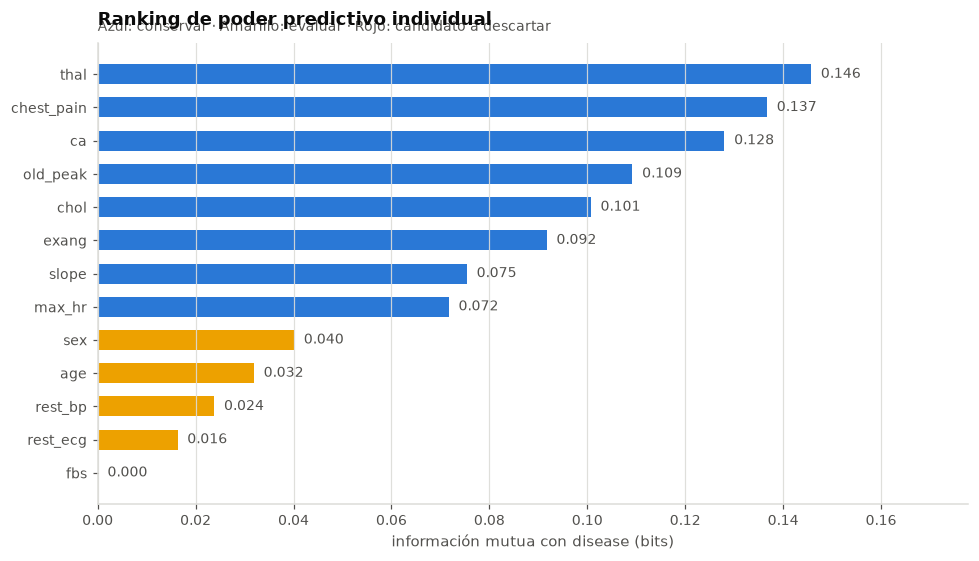

In [23]:
fig, ax = plt.subplots(figsize=(9, 5.2))
d = ranking.sort_values("información mutua")
colores = [
    PAL[0] if r == "conservar" else PAL[3] if r == "evaluar" else PAL[7]
    for r in d["recomendación"]
]
b = ax.barh(d.index, d["información mutua"], color=colores, height=0.6)
for rect, v in zip(b, d["información mutua"]):
    ax.text(
        v + 0.002,
        rect.get_y() + rect.get_height() / 2,
        f"{v:.3f}",
        va="center",
        fontsize=9,
        color=TXT2,
    )
ax.set_xlim(0, d["información mutua"].max() * 1.22)
ax.set_xlabel("información mutua con disease (bits)")
ax.grid(axis="y", visible=False)
titulo(
    ax,
    "Ranking de poder predictivo individual",
    "Azul: conservar · Amarillo: evaluar · Rojo: candidato a descartar",
)
plt.tight_layout()
plt.show()

---
## 7. Conclusiones del análisis bivariable

### 7.1 Qué predice la enfermedad

Los atributos se ordenan en **tres niveles** consistentes en los tres criterios usados
(tamaño del efecto, V de Cramér e información mutua):

| Nivel | Atributos | Interpretación |
|---|---|---|
| **Fuerte** | `thal`, `ca`, `chest_pain`, `old_peak`, `max_hr` | Marcadores anatómicos e isquémicos directos. Núcleo de cualquier modelo. |
| **Moderado** | `exang`, `slope`, `age`, `sex` | Señal real pero parcialmente solapada con el nivel fuerte. |
| **Débil / nulo** | `rest_bp`, `chol`, `fbs`, `rest_ecg` | Aportan poco por separado. `fbs` es candidata clara a eliminación. |

### 7.2 Estructura de la información

Los predictores útiles se agrupan en **tres bloques temáticos**, y dentro de cada bloque
las variables miden en gran medida lo mismo:

1. **Bloque anatómico** — `ca`, `thal`: extensión de la obstrucción, medida directamente.
2. **Bloque isquémico** — `old_peak`, `slope`, `exang`, `max_hr`: respuesta al esfuerzo.
   Es el bloque que justifica el atributo derivado `isquemia` propuesto en el Notebook 1.
3. **Bloque demográfico** — `age`, `sex`: riesgo basal.

Dentro del bloque isquémico sí hay solapamiento apreciable —`old_peak` ~ `slope` (ρ ≈ 0,59)
y `chest_pain` ~ `exang` (V ≈ 0,45) miden aspectos muy próximos del mismo fenómeno— pero
**entre bloques la redundancia es baja**. Conviene que el modelo final incluya al menos un
representante de cada bloque, y considerar reducir el bloque isquémico a un único índice
compuesto (el atributo `isquemia` propuesto en el Notebook 1).

### 7.3 Advertencias metodológicas

- **`rest_ecg` no es interpretable tal como está**: la categoría `ST-T wave abnormality`
  tiene 4 casos y genera celdas esperadas < 5, lo que invalida su χ². Debe fusionarse
  antes de cualquier conclusión.
- **Significación ≠ relevancia**: con n=297 varias variables alcanzan p<0,05 con tamaños
  de efecto insignificantes. La selección de atributos se hizo por magnitud del efecto,
  no por p-valor.
- **Todo lo anterior es asociación, no causalidad.** `sex` ilustra el riesgo: su
  asociación con `disease` está confundida con la composición de la cohorte (68% hombres,
  derivación clínica sesgada), no es un efecto causal estimable con estos datos.
- Estos resultados serían **irreproducibles sobre el archivo crudo**: con 3.030 filas
  replicadas, cada p-valor sería ~10 veces más pequeño de lo que corresponde.

**Siguiente paso →** el *Notebook 3 — Análisis Multivariable* examina cómo interactúan los
atributos en conjunto (PCA, agrupamiento, colinealidad) y construye un **modelo heurístico
manual** para establecer la línea base del proyecto.